<a id='top'></a>

------

CSCI E-82 Advanced Machine Learning, Data Mining and Artificial Intelligence
=====

# Section 2:  12 September 2026, 11am EDT

TA: *Simili Abhilash*

Contributor(s) : *Daniel Sauble*

------

Topics for this section
==================

### Intro

- [Grading Tips](#tips)
- [Loading datasets](#datasets)

### Dimensionality reduction topics

- [PCA](#pca) (baseline)
- [t-SNE](#tsne)
- [UMAP](#umap)
- [MDS](#mds)
- [Sammons Mapping (For Reference)](#sammons)
- [Isomap (For Reference)](#isomap)
- [Qualitative comparison](#qualitative_comparison)
- [Shepard Plots (For Reference)](#shepard)

------

[Back to Top](#top)
<a id="tips"></a>

## Grading Tips

* Show what worked as well as what didn't.
* Label your charts so we understand what you're showing us.
* Keep it concise. If you find yourself submitting hundreds of pages of work, it's possible that you're including output (e.g. debug output) that we don't need to see.
* Convert Jupyter Notebooks to a PDF to make it easier for us to view your submissions. Make sure content isn't cropped out of the PDF!
* Submit both the .ipynb file and the PDF file

### To convert to PDF

1. Install [nbconvert](https://nbconvert.readthedocs.io/en/latest/install.html)
2. Install [Pandoc](https://pandoc.org/installing.html)
3. Install [LaTeX](https://www.latex-project.org/get/#tex-distributions)
4. Run `jupyter nbconvert --to pdf notebook.ipynb` on the command line, or… File -> Save and Export Notebook as -> PDF
5. Alternatively, File -> Save and Export Notebook As -> HTML, then open the HTML in your browser and save as PDF (make sure all your content is intact)
   
[Back to Top](#top)
<a id="environment"></a>

## Setting up the environment

See Section 1 notebook

## Start Jupyter notebook

Now you can start Jupyter Notebook:

```
jupyter notebook
```

## Import dependencies

Now, let's import some dependencies:

In [2]:
# Datasets
from sklearn import datasets

# Utilities
import numpy as np
import pandas as pd
import time

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.manifold import MDS
from sklearn.manifold import Isomap
import umap # Note: %pip install umap-learn

# Metrics
from sklearn.metrics import euclidean_distances

# Visualization
from matplotlib import offsetbox
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

#change this to 'once' if you want to see msgs once
import warnings
warnings.filterwarnings('ignore') 

%matplotlib inline

[Back to Top](#top)
<a id="datasets"></a>

## Load Datasets

### Digits
Dataset of handwritten digits from 0-9
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html

https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits

Example: Loading using scikit-learn built-in function

In [3]:
digits = datasets.load_digits()
digits_X = digits.data
digits_Y = digits.target
n_samples, n_features = digits_X.shape
n_neighbors = 30
print(digits_X.shape)
print(digits_Y.shape)

(1797, 64)
(1797,)


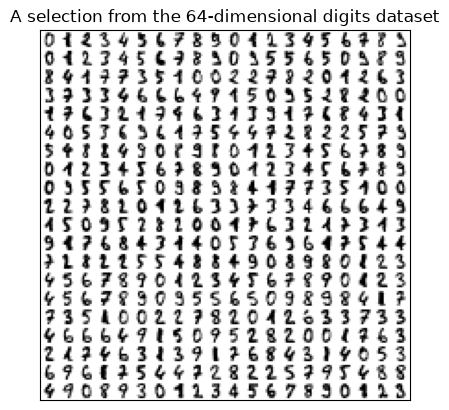

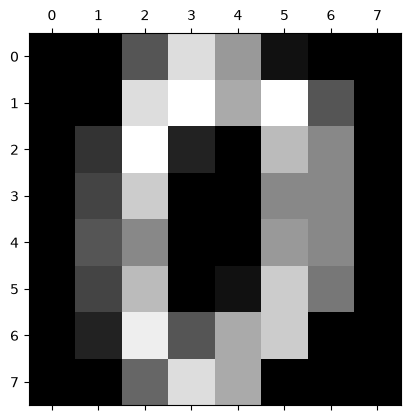

In [4]:
# Source: https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html#sphx-glr-auto-examples-manifold-plot-lle-digits-py 

# Plot images of the digits
n_img_per_row = 20
img = np.zeros((10 * n_img_per_row, 10 * n_img_per_row))
for i in range(n_img_per_row):
    ix = 10 * i + 1
    for j in range(n_img_per_row):
        iy = 10 * j + 1
        img[ix:ix + 8, iy:iy + 8] = digits_X[i * n_img_per_row + j].reshape((8, 8))

plt.imshow(img, cmap=plt.cm.binary)
plt.xticks([])
plt.yticks([])
plt.title('A selection from the 64-dimensional digits dataset');

# show 1 images (8x8 = 64 pixel)
plt.matshow(digits.images[0], cmap="gray")

### Fashion MNIST

Dataset of fashion images of different types of clothing

Example: Loading an [openml](https://www.openml.org/) dataset through scikit-learn

In [7]:
dataset = datasets.fetch_openml("Fashion-MNIST", version=1, as_frame=False)
X = dataset.data
Y = dataset.target

(trainX, testX) = (X[:60000], X[60000:])
(trainY, testY) = (Y[:60000], Y[60000:])
print(trainX.shape, trainY.shape, testX.shape, testY.shape)

fashion_mnist_classes = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal', 'Shirt','Sneaker','Bag','Ankle boot']
fashion_mnist_X = np.array(testX[:4000], dtype=np.float64) / 255.0
fashion_mnist_X = fashion_mnist_X.reshape(-1,784)
fashion_mnist_Y = testY[:4000]
fashion_mnist_Y = fashion_mnist_Y.reshape(-1,1)
print(fashion_mnist_X.shape, fashion_mnist_Y.shape)

(60000, 784) (60000,) (10000, 784) (10000,)
(4000, 784) (4000, 1)


### US Cities

Dataset of “straight line” distances between 10 cities in the US.

Example: Loading a dataset from a file, using Pandas


In [8]:
#Dataset from R USCitiesD (library datasets)
uscitiesd = pd.read_csv("./data/UScitiesD.csv")
print(uscitiesd.shape)
uscitiesd

(10, 11)


,0,Atlanta,Chicago,Denver,Houston,LosAngeles,Miami,NewYork,SanFrancisco,Seattle,Washington.DC
0,Atlanta,0,587,1212,701,1936,604,748,2139,2182,543
1,Chicago,587,0,920,940,1745,1188,713,1858,1737,597
2,Denver,1212,920,0,879,831,1726,1631,949,1021,1494
3,Houston,701,940,879,0,1374,968,1420,1645,1891,1220
4,LosAngeles,1936,1745,831,1374,0,2339,2451,347,959,2300
5,Miami,604,1188,1726,968,2339,0,1092,2594,2734,923
6,NewYork,748,713,1631,1420,2451,1092,0,2571,2408,205
7,SanFrancisco,2139,1858,949,1645,347,2594,2571,0,678,2442
8,Seattle,2182,1737,1021,1891,959,2734,2408,678,0,2329
9,Washington.DC,543,597,1494,1220,2300,923,205,2442,2329,0


In [9]:
uscitiesd_X = uscitiesd.iloc[:,1:]
uscitiesd_Y = uscitiesd.iloc[:,0:1]

print(uscitiesd_X.head())

   Atlanta  Chicago  Denver  Houston  LosAngeles  Miami  NewYork  \
0        0      587    1212      701        1936    604      748   
1      587        0     920      940        1745   1188      713   
2     1212      920       0      879         831   1726     1631   
3      701      940     879        0        1374    968     1420   
4     1936     1745     831     1374           0   2339     2451   

   SanFrancisco  Seattle  Washington.DC  
0          2139     2182            543  
1          1858     1737            597  
2           949     1021           1494  
3          1645     1891           1220  
4           347      959           2300  


### UCI Automobile

Dataset of automobile specifications, insurance risk rating, and normalized losses in use compared to other cars

https://archive.ics.uci.edu/ml/datasets/Automobile

Example: Loading a dataset from a url, using Pandas

In [10]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'
auto = pd.read_csv(url, sep=',', header=None)

auto.replace('?', np.nan, inplace=True)
auto.dropna(axis=0, how='any', inplace=True)
auto[1] = auto[1].astype('int64')
auto.columns = ['symboling','normalized-losses','make','fuel-type','aspiration','num-of-doors','body-style','drive-wheels','engine-location',
'wheel-base','length','width','height','curb-weight','engine-type','num-of-cylinders','engine-size','fuel-system',
'bore','stroke','compression-ratio', 'horsepower','peak-rpm', 'city-mpg', 'highway-mpg', 'price']

auto['bore'] = auto['bore'].astype('float64')
auto['stroke'] = auto['stroke'].astype('float64') 
auto['horsepower'] = auto['horsepower'].astype('float64') 
auto['peak-rpm'] = auto['peak-rpm'].astype('float64') 
auto['price'] = auto['price'].astype('float64') 
auto['price'] = auto['price'].astype('float64') 
auto.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102.0,5500.0,24,30,13950.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115.0,5500.0,18,22,17450.0
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110.0,5500.0,19,25,17710.0
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140.0,5500.0,17,20,23875.0
10,2,192,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.8,8.8,101.0,5800.0,23,29,16430.0


In [12]:
auto_X = auto.drop(auto.dtypes[auto.dtypes=='object'].index, axis=1)
# or auto_X = auto.select_dtypes(include=np.number) 

auto_Y = pd.DataFrame(auto_X.columns.values, columns=["Feature"])
auto_X = 1-np.array(auto_X.corr()) # Compute dissimilarity matrix by subtracting the correlation matrix from 1

[Back to Top](#top)
<a id='pca'></a>

## PCA (baseline)

This was covered in Week 1, so we're just including a helper function here to compare against t-SNE, UMAP, MDS, Sammons Mapping, and Isomap.

In [13]:
def pca_fit_transform(data):
    return PCA(n_components=2).fit_transform(data)

[Back to Top](#top)
<a id='tsne'></a>

##  t-SNE: t-Distributed Stochastic Neighbor Embedding

### Algorithm

The goal of t-SNE is to take a set of points in a high-dimensional space and find a faithful representation of those points in a lower-dimensional space, typically the 2D plane. The algorithm is non-linear and adapts to the underlying data, performing different transformations on different regions.

T-SNE converts similarities between data points to joint probabilities and tries to minimize the Kullback-Leibler divergence between the joint probabilities of the low-dimensional embedding and the high-dimensional data. t-SNE has a cost function that is not convex, i.e. with different initializations we can get different results.

More info:

* [original t-SNE paper](http://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf) and [website](https://lvdmaaten.github.io/tsne/) 
* [good video about t-SNE](https://www.youtube.com/watch?v=NEaUSP4YerM)
* [Parameters reference](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)
* [How to Use t-SNE Effectively](http://distill.pub/2016/misread-tsne/)
* [Interesting t-SNE visualization](https://ml4a.github.io/demos/tsne_viewer.html)
* [Clustering on the output of t-SNE](https://stats.stackexchange.com/questions/263539/clustering-on-the-output-of-t-sne)

### Strengths and weaknesses

Compared with PCA, t-SNE is slower but works better on non-linear datasets. Whereas PCA preserves the global structure, t-SNE gives you the flexibility to preserve local vs. global structure via the `perplexity` parameter.

See [this](https://datascience.stackexchange.com/questions/36889/what-does-it-mean-by-t-sne-retains-the-structure-of-the-data)  for more on **local vs. global structure**. In short, t-SNE is able to preserve local structure by computing a metric between each datapoint and a given number of neighbours - modelling them as being within a t-distributed distribution. It then tries to find an embedding, such that neighbours in the original n-dimensional space, are also found close together in the reduced (embedded) dimensional space. It does this by minimising the KL-divergence between the before and after datapoint distributions, ℙ and ℚ respectively.

NOTES ON PERFORMANCE:

1. To speed up t-SNE, it is highly recommended to use another dimensionality reduction method (e.g. PCA for dense data or TruncatedSVD for sparse data) to reduce the number of dimensions to a reasonable amount (e.g. 50) if the number of features is very high. This will suppress some noise and speed up the computation of pairwise distances between samples. You can pass `init="pca"` to TSNE to have it do this for you.
2. You can also try running t-SNE on GPU: E.g., Fashion MNIST with GPU https://www.kaggle.com/code/tunguz/mnist-2d-t-sne-with-rapids
 
### Available parameters

The major t-SNE parameters are:

* `perplexity` - manage global vs local focus on your data. The parameter is, in a sense, a guess about the number of close neighbors each point has. Lower values of perplexity tend to preserve the local structure and higher values of perplexity tend to preserve the global structure.
* `learning_rate` - The learning rate for t-SNE is usually in the range [10.0, 1000.0]. If the learning rate is too high, the data may look like a ‘ball’ with any point approximately equidistant from its nearest neighbours. If the learning rate is too low, most points may look compressed in a dense cloud with few outliers. If the cost function gets stuck in a bad local minimum increasing the learning rate may help.
* `max_iter` - The maximum number of iterations for the optimization. By setting number of iteration, you should aim to iterate until you reach stable configuration.
* `random_state` - t-SNE is stochastic, so in your notebook you may find it helpful to set this parameter so that every run results in the same output

More parameters listed in the [scikit-learn docs](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).

### Example

NOTE: Some caveats about the results from t-SNE. 1) One can't see relative size of the clusters on t-SNE plots since by design algorithm would expand dense clusters and contract sparse ones. Also, 2) distances between clusers might have no meaning. t-SNE is flexible, yet tricky to interpret


In [14]:
%%time

def tsne_fit_transform(data):
    #tsne = TSNE(n_components=2, random_state=0, perplexity=43, max_iter=5000, learning_rate=100, init="pca")
    tsne = TSNE(n_components=2, perplexity=9)
    return tsne.fit_transform(data)

X_tsne = tsne_fit_transform(digits_X)

CPU times: user 5.88 s, sys: 1.15 s, total: 7.03 s
Wall time: 1.71 s


In [15]:
X_tsne_df = pd.DataFrame(X_tsne)
X_tsne_df.columns = ['_DIM_1_','_DIM_2_']
X_tsne_df['Label'] = digits_Y

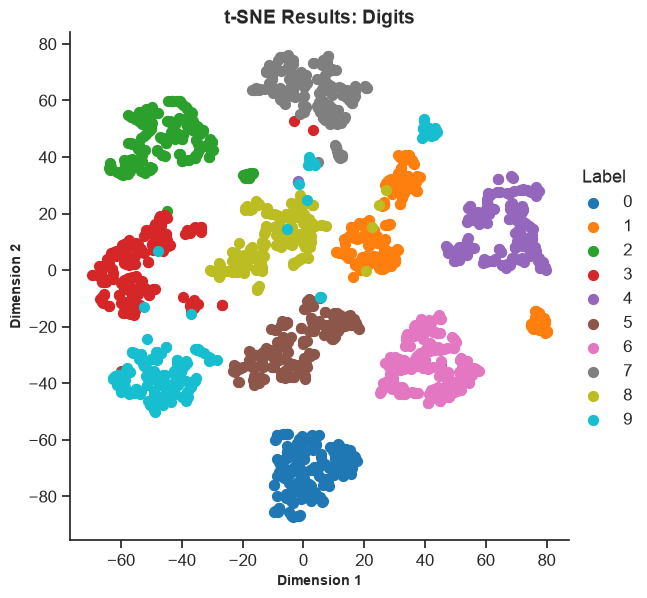

In [16]:
#https://towardsdatascience.com/mastering-t-sne-a-comprehensive-guide-to-understanding-and-implementation-in-python-480929bfe6f4/

def tsne_plot(data, title):
    # Plot Digits t-SNE
    sns.set_context("notebook", font_scale=1.1)
    sns.set_style("ticks")

    sns.lmplot(x='_DIM_1_',
               y='_DIM_2_',
               data=data,
               fit_reg=False,
               legend=True,
               height=6,
               hue='Label',
               scatter_kws={"s":50, "alpha":1})

    plt.title(title, weight='bold').set_fontsize('14')
    plt.xlabel('Dimension 1', weight='bold').set_fontsize('10')
    plt.ylabel('Dimension 2', weight='bold').set_fontsize('10')

tsne_plot(X_tsne_df, 't-SNE Results: Digits')

In the above plot it would be interesting to analyze blue (9) point that seem to be in the brown (5) region.  May be the images look similar or misclassified.  Similarly there are few more points for e.g blue point(9) that appears in the red (3) region. Keep in mind the distances between clusters do not mean much, also size (density) of the cluster do not mean much. It's obvious that we see clusters by their corresponding digits - if we analyze any cluster further we may notice patterns for e.g.: all 1's that are slanted to left or right appear on the one side of the cluster.

What happens when we play with the parameters?

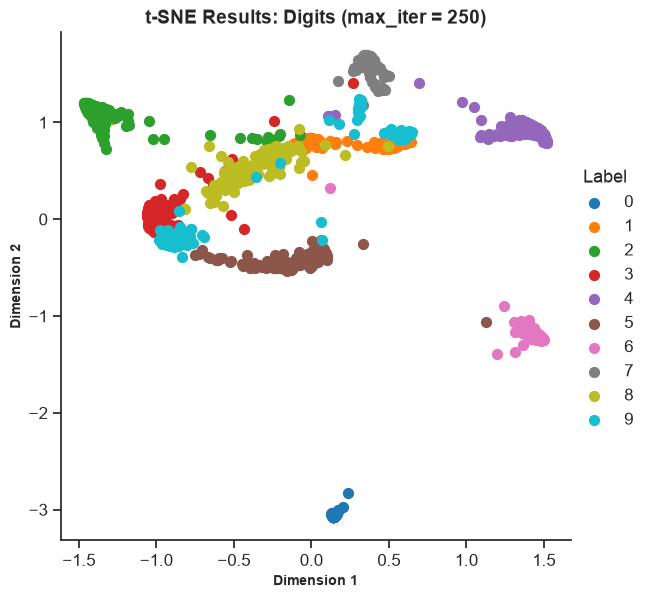

In [17]:
# Change max_iter from 5000 to 250
tsne = TSNE(n_components=2, random_state=0, perplexity=43, max_iter=250, learning_rate=100 )
X_tsne = tsne.fit_transform(digits_X)

X_tsne_df = pd.DataFrame(X_tsne)
X_tsne_df.columns = ['_DIM_1_','_DIM_2_']
X_tsne_df['Label'] = digits_Y

tsne_plot(X_tsne_df, 't-SNE Results: Digits (max_iter = 250)')

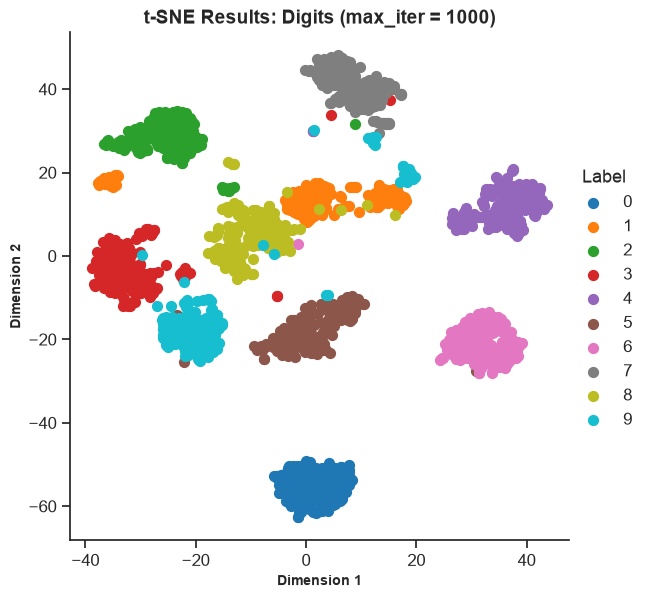

In [18]:
# max_iter = 1000
tsne = TSNE(n_components=2, random_state=0, perplexity=43, max_iter=1000, learning_rate=100)
X_tsne = tsne.fit_transform(digits_X)

X_tsne_df = pd.DataFrame(X_tsne)
X_tsne_df.columns = ['_DIM_1_','_DIM_2_']
X_tsne_df['Label'] = digits_Y

tsne_plot(X_tsne_df, 't-SNE Results: Digits (max_iter = 1000)')

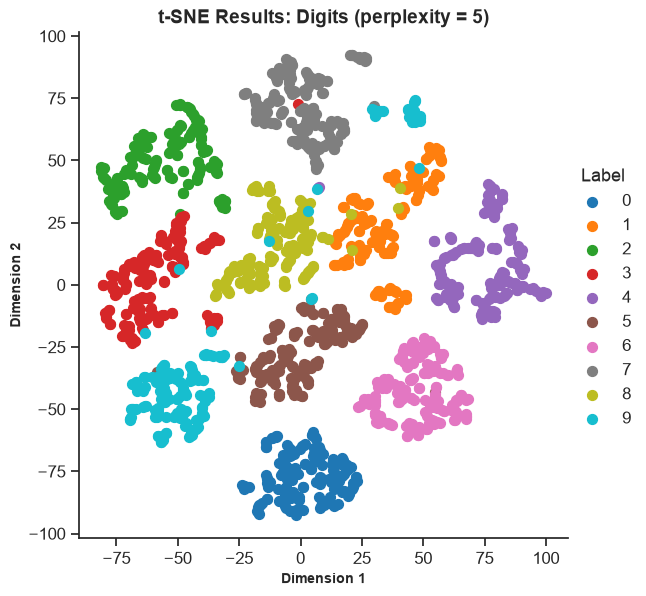

In [19]:
# perplexity = 5
tsne = TSNE(n_components=2, random_state=0, perplexity=5, max_iter=1000, learning_rate=100 )
X_tsne = tsne.fit_transform(digits_X)

X_tsne_df = pd.DataFrame(X_tsne)
X_tsne_df.columns = ['_DIM_1_','_DIM_2_']
X_tsne_df['Label'] = digits_Y

tsne_plot(X_tsne_df, 't-SNE Results: Digits (perplexity = 5)')

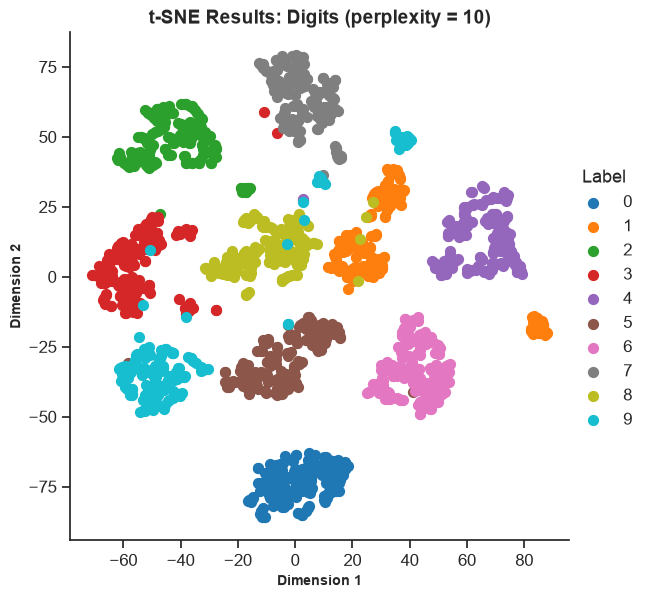

In [20]:
# perplexity = 10
tsne = TSNE(n_components=2, random_state=0, perplexity=10, max_iter=1000, learning_rate=100 )
X_tsne = tsne.fit_transform(digits_X)

X_tsne_df = pd.DataFrame(X_tsne)
X_tsne_df.columns = ['_DIM_1_','_DIM_2_']
X_tsne_df['Label'] = digits_Y

tsne_plot(X_tsne_df, 't-SNE Results: Digits (perplexity = 10)')

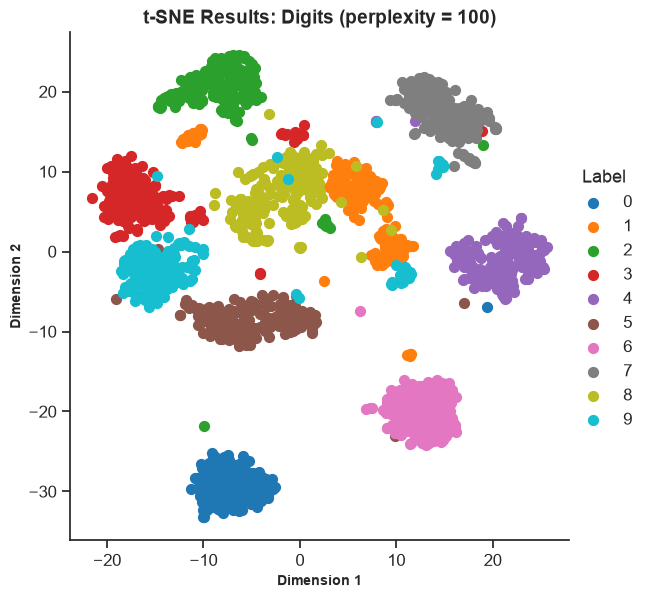

In [21]:
# perplexity = 100
tsne = TSNE(n_components=2, random_state=0, perplexity=100, max_iter=1000, learning_rate=100 )
X_tsne = tsne.fit_transform(digits_X)

X_tsne_df = pd.DataFrame(X_tsne)
X_tsne_df.columns = ['_DIM_1_','_DIM_2_']
X_tsne_df['Label'] = digits_Y

tsne_plot(X_tsne_df, 't-SNE Results: Digits (perplexity = 100)')

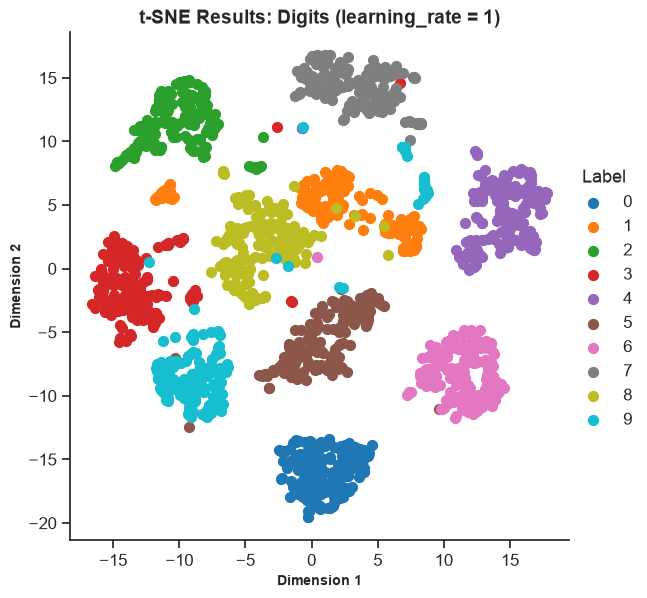

In [22]:
# learning_rate = 1
tsne = TSNE(n_components=2, random_state=0, perplexity=43, max_iter=1000, learning_rate=1 )
X_tsne = tsne.fit_transform(digits_X)

X_tsne_df = pd.DataFrame(X_tsne)
X_tsne_df.columns = ['_DIM_1_','_DIM_2_']
X_tsne_df['Label'] = digits_Y

tsne_plot(X_tsne_df, 't-SNE Results: Digits (learning_rate = 1)')

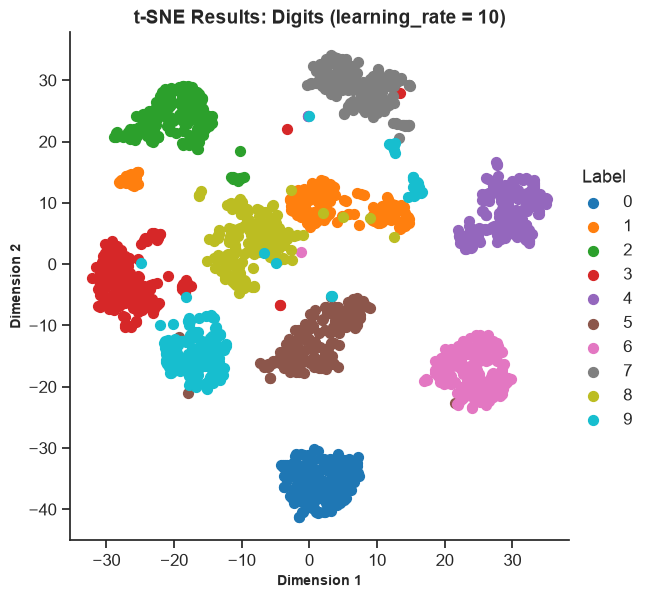

In [23]:
# learning_rate = 10
tsne = TSNE(n_components=2, random_state=0, perplexity=43, max_iter=1000, learning_rate=10)
X_tsne = tsne.fit_transform(digits_X)

X_tsne_df = pd.DataFrame(X_tsne)
X_tsne_df.columns = ['_DIM_1_','_DIM_2_']
X_tsne_df['Label'] = digits_Y

tsne_plot(X_tsne_df, 't-SNE Results: Digits (learning_rate = 10)')

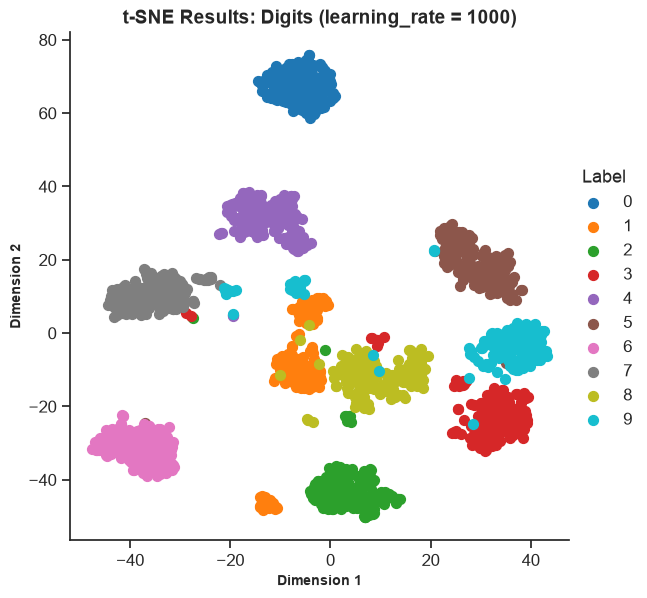

In [24]:
# learning_rate = 1000
tsne = TSNE(n_components=2, random_state=0, perplexity=43, max_iter=1000, learning_rate=1000)
X_tsne = tsne.fit_transform(digits_X)

X_tsne_df = pd.DataFrame(X_tsne)
X_tsne_df.columns = ['_DIM_1_','_DIM_2_']
X_tsne_df['Label'] = digits_Y

tsne_plot(X_tsne_df, 't-SNE Results: Digits (learning_rate = 1000)')

### t-SNE with the Fashion MNIST dataset

In [25]:
sns.set(style='white', context='poster')
cmap = LinearSegmentedColormap.from_list('mycmap', ['red', 'green', 'blue', 'black', 'yellow', 'pink', 'brown', 'aquamarine', 'mediumpurple' ,'orange'])

In [26]:
%%time
tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(fashion_mnist_X)

CPU times: user 20.3 s, sys: 1.96 s, total: 22.3 s
Wall time: 4.52 s


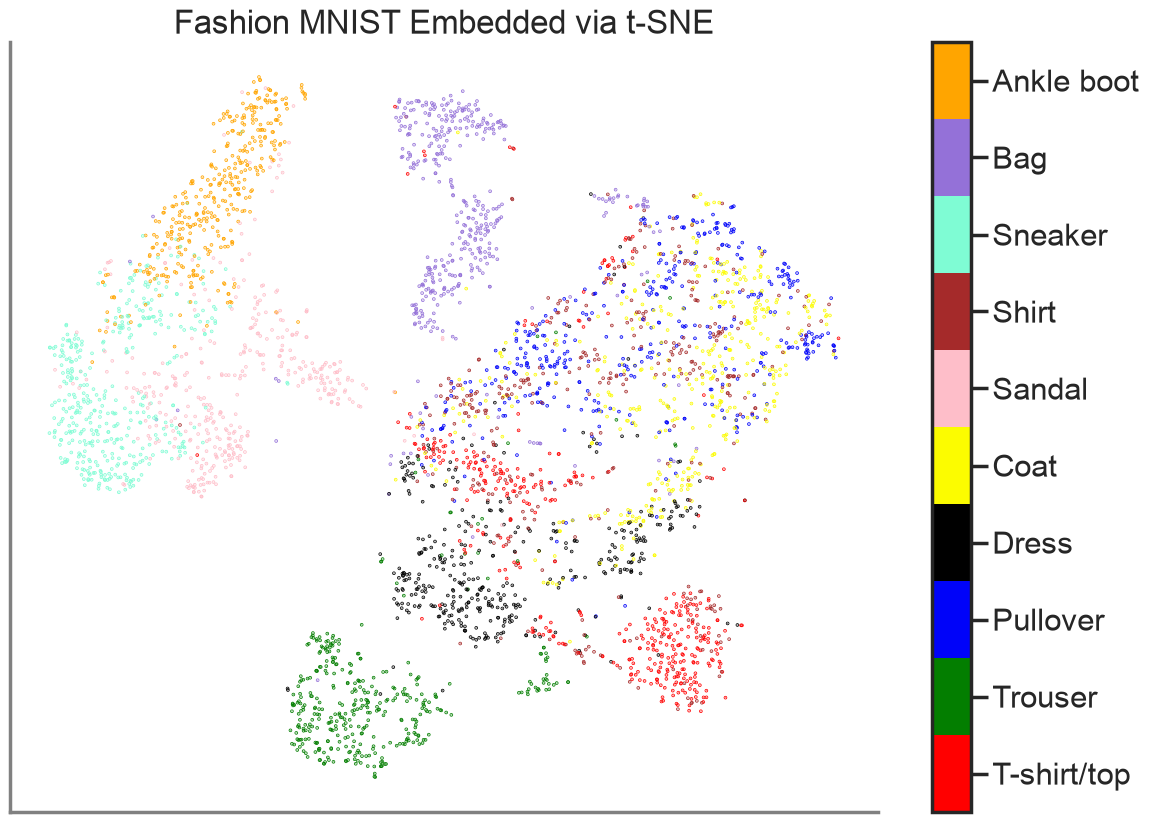

In [27]:
fig, ax = plt.subplots(1, figsize=(14, 10))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=0.3, c=fashion_mnist_Y, cmap=cmap, alpha=1.0)
plt.setp(ax, xticks=[], yticks=[])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.setp(ax.spines.values(), color='grey')

cbar = plt.colorbar(boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(fashion_mnist_classes)
plt.title('Fashion MNIST Embedded via t-SNE');

[Back to Top](#top)
<a id="umap"></a>

## UMAP

![image](img/umap_image.png)


### Algorithm

From https://pair-code.github.io/understanding-umap/

> In order to construct the initial high-dimensional graph, UMAP builds something called a "fuzzy simplicial complex". This is really just a representation of a weighted graph, with edge weights representing the likelihood that two points are connected. To determine connectedness, UMAP extends a radius outwards from each point, connecting points when those radii overlap. Choosing this radius is critical - too small a choice will lead to small, isolated clusters, while too large a choice will connect everything together. UMAP overcomes this challenge by choosing a radius locally, based on the distance to each point's nth nearest neighbor. UMAP then makes the graph "fuzzy" by decreasing the likelihood of connection as the radius grows. Finally, by stipulating that each point must be connected to at least its closest neighbor, UMAP ensures that local structure is preserved in balance with global structure. Once the high-dimensional graph is constructed, UMAP optimizes the layout of a low-dimensional analogue to be as similar as possible. This process is essentially the same as in t-SNE, but using a few clever tricks to speed up the process.

More info:

* UMAP paper - https://arxiv.org/abs/1802.03426
* Paper reading on youtube - https://www.youtube.com/watch?v=G9s3cE8TNZo&t=209s
* Interactive tool for trying out UMAP vs. t-SNE and PCA - https://projector.tensorflow.org/
* Understanding UMAP - https://pair-code.github.io/understanding-umap/
* Python library umap-Learn - https://umap-learn.readthedocs.io/en/latest/api.html

### Strengths and weaknesses

Compared to t-SNE, UMAP is much faster (10x faster on many datasets) and more robust, while providing a similar ability to flexibly choose between preserving local or global structure. As a result, UMAP is commonly used as a replacement for t-SNE, especially with larger datasets with more dimensions.

### Available parameters

The major UMAP parameters are:

* `n_neighbors` - determines balance of local vs global structure. It constrains the size of the local neighborhood that UMAP method looks at, when attempting to learn manifold structure. Low values brings out local structure, large bring out larger neighborhoods while losing the fine detail.
* `min_dist` - determines the minimum distance apart points are allowed to be in the embedding. Low values will result in clumpier embeddings which is good for finer topological structure. Larger values is useful to visualize broad topological structure.
* `metric` - controls how the distance is computed in input data. Many metrics are built-in ([see metric options in documentation](https://umap-learn.readthedocs.io/en/latest/parameters.html#metric)), but they can also be defined if compiled with [numba](https://numba.pydata.org/).

More parameters listed in the [umap-learn docs](https://umap-learn.readthedocs.io/en/latest/parameters.html).

### Example

In [28]:
#https://umap-learn.readthedocs.io/en/latest/supervised.html
#% pip install umap-learn

sns.set(style='white', context='poster')
cmap = LinearSegmentedColormap.from_list('mycmap', ['red', 'green', 'blue', 'black', 'yellow', 'pink', 'brown', 'aquamarine', 'mediumpurple' ,'orange'])

In [29]:
%%time
def umap_fit_transform(data):
    return umap.UMAP(n_neighbors=5).fit_transform(data)
embedding = umap_fit_transform(fashion_mnist_X)

CPU times: user 13 s, sys: 340 ms, total: 13.3 s
Wall time: 10.2 s


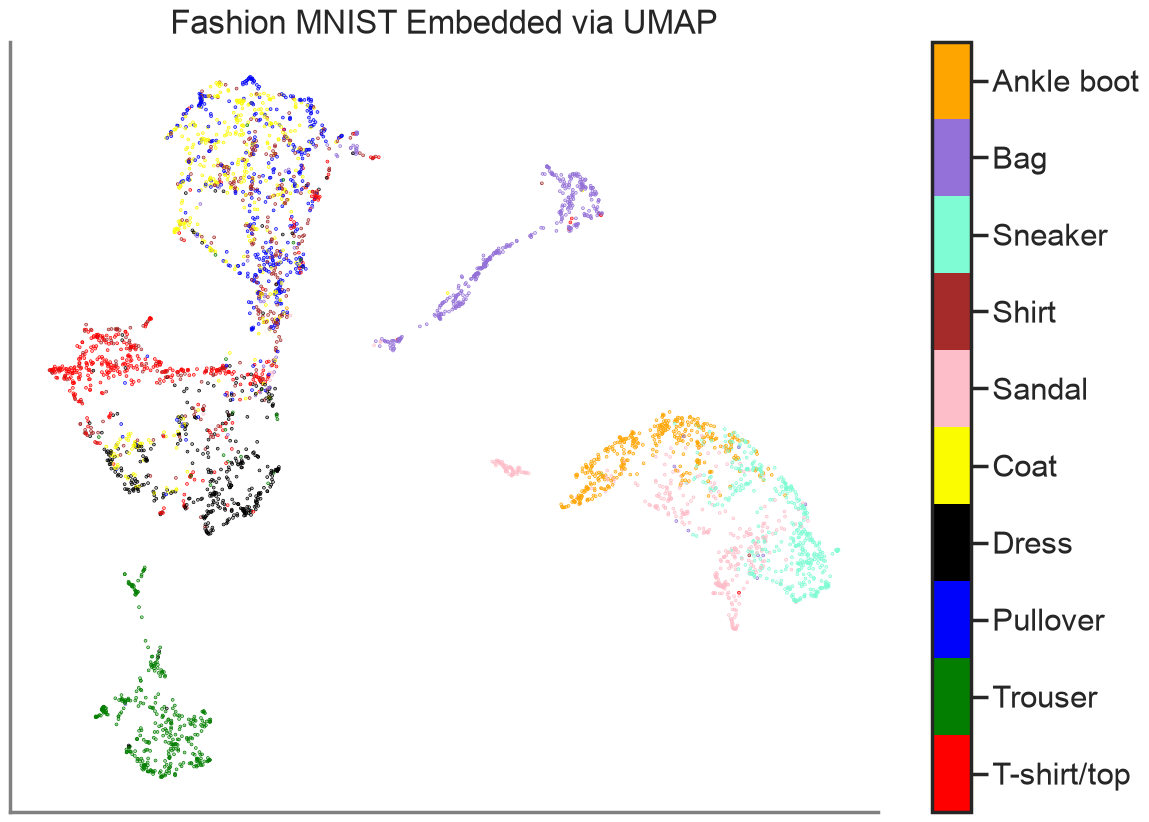

In [30]:
fig, ax = plt.subplots(1, figsize=(14, 10))
plt.scatter(*embedding.T, s=0.3, c=fashion_mnist_Y, cmap=cmap, alpha=1.0)
plt.setp(ax, xticks=[], yticks=[])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.setp(ax.spines.values(), color='grey')

cbar = plt.colorbar(boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))
cbar.set_ticklabels(fashion_mnist_classes)
plt.title('Fashion MNIST Embedded via UMAP');

t-SNE and UMAP both exhibit strong local clustering and group similar categories together, UMAP much more clearly separates these groups of similar categories from each other. Also consider the time taken when we you run t-SNE and UMAP.  There are some red (T-shirt/top) points  that appear in medium purple (Bag) color, we can further analyze those points. UMAP also seem to have merged the pullover and coat category. 

[Back to Top](#top)
<a id='mds'></a>

## Multi-Dimensional Scaling


### Algorithm

Multidimensional scaling (MDS) is a form of nonlinear dimensionality reduction that learns the similarity of points in the original dataset and, using this similarity learning, models this in a lower dimensional space. It expects a dissimilarity matrix. Absolute distances is one way to measure it for ordinal data types (those that can be counted). Besides euclidean method other ways to measure distances include:

1. Manhattan Distance,
2. Hamming Distance,
3. Great Circle Distance
4. Log fold change (frequently used among biologists)

Selecting the best distance measure is a very important step.

MDS is enabled through optimization. There are various options of nonlinear minimization functions in optimization packages from sci-kit learn, scipy, etc. Most commonly used gradient descent.

More info:

* scikit-learn docs: http://scikit-learn.org/stable/modules/manifold.html#multidimensional-scaling
* Building Machine Learning Systems with Python  By: Willi Richert; Luis Pedro Coelho: http://totoharyanto.staff.ipb.ac.id/files/2012/10/Building-Machine-Learning-Systems-with-Python-Richert-Coelho.pdf

### Strengths and weaknesses

PCA and MDS both used for reducing dimensionality of data. Whereas PCA tries to use optimization for retained variance, MDS tries to retain the relative distances as much as possible when reducing the dimensions. This is useful when we have a high-dimensional dataset and want to get a visual impression.  

### Available parameters

The major MDS parameters are:

* `n_components` - number of components in which to immerse the dissimilarities
* `dissimilarity` - even though MDS expects a dissimilarity matrix, by default it computes the dissimilarity matrix from data passed to `fit` and `fit_transform`. If you'd rather compute the dissimilarity matrix yourself, you can set this parameter to "euclidean" instead.

More parameters listed in the [scikit-learn docs](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html).

### Example

**But first, a brief aside about dissimiliarity vs. similarity measures**

* Similarity - How alike two objects are, minimum -1 or 0 => Not alike, maximum 1 => complete similarity  (Correlation coefficient, Cosine Similarity) 
* Dissimilarity - How different two objects are, minimum 0 (same object), maximum $\infty$ => Not at all similar (different objects) = Euclidean distance

In [32]:
print(uscitiesd_X.shape)

def mds_fit_transform(data):
    #Default metric = True, for NonMetric set metric=False
    mds = MDS(n_components=2, dissimilarity="euclidean", random_state=99)  
    return mds.fit_transform(data)  # shape (n_samples, n_components)

mds_fit = mds_fit_transform(uscitiesd_X)

(10, 10)


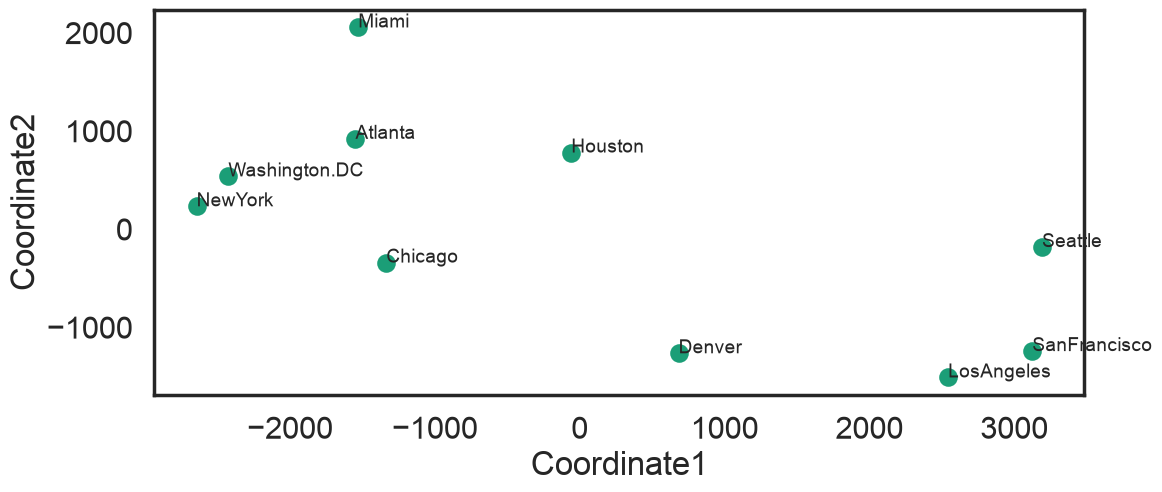

In [34]:
x1 = mds_fit[:,0]
y1 = mds_fit[:,1]

fig, ax = plt.subplots(figsize=(12,5))

dark2_colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02','#a6761d','#666666']
shade_black = '#262626'
ax.scatter(x1,y1, s = 130, zorder=0, c=dark2_colors[0])

for i, txt in enumerate(uscitiesd_Y.values):
    ax.annotate(txt[0], (x1[i],y1[i]), zorder=1, size=14, color=shade_black)
    
ax.set_xlabel('Coordinate1')
ax.set_ylabel('Coordinate2');

We see that relative distances are preserved between cities.

### Visualizing a correlation matrix using Multidimensional Scaling

http://www.sthda.com/english/articles/31-principal-component-methods-in-r-practical-guide/122-multidimensional-scaling-essentials-algorithms-and-r-code/

MDS can be also used to reveal a hidden pattern in a correlation matrix. Correlation actually measures similarity, but it is easy to transform it to a measure of dissimilarity. Distance between objects can be calculated as `1 - corr`.


Correlation heatmap is another option to visualize correlation matrix. 

In [35]:
mds = MDS(n_components=2, dissimilarity="euclidean", random_state=99)  

mds_fit = mds.fit_transform(auto_X)  # shape (n_samples, n_components)

In [36]:
auto_X

array([[0.        , 0.48165636, 1.52059057, 1.33625676, 1.21918597,
        1.47518487, 1.25187998, 1.1094533 , 1.25646934, 1.02128509,
        1.13831574, 1.00394909, 0.80089443, 0.91045037, 0.85016993,
        1.16279428],
       [0.48165636, 0.        , 1.06008568, 0.96445929, 0.8902738 ,
        1.41370154, 0.87414208, 0.79218039, 1.03155814, 0.93666952,
        1.1272591 , 0.70948945, 0.76230338, 1.23552348, 1.1885642 ,
        0.7972387 ],
       [1.52059057, 1.06008568, 0.        , 0.12846552, 0.18500875,
        0.44423287, 0.18981851, 0.35079442, 0.42184147, 0.83255132,
        0.70856855, 0.48305247, 1.28923445, 1.5806572 , 1.6117499 ,
        0.26558106],
       [1.33625676, 0.96445929, 0.12846552, 0.        , 0.16166154,
        0.50074863, 0.12870892, 0.27404669, 0.35368245, 0.87892692,
        0.81518582, 0.3279367 , 1.23407384, 1.72454445, 1.72459867,
        0.23904782],
       [1.21918597, 0.8902738 , 0.18500875, 0.16166154, 0.        ,
        0.7072942 , 0.12940547, 

In [37]:
np.array(auto_X).shape, mds_fit.shape

((16, 16), (16, 2))

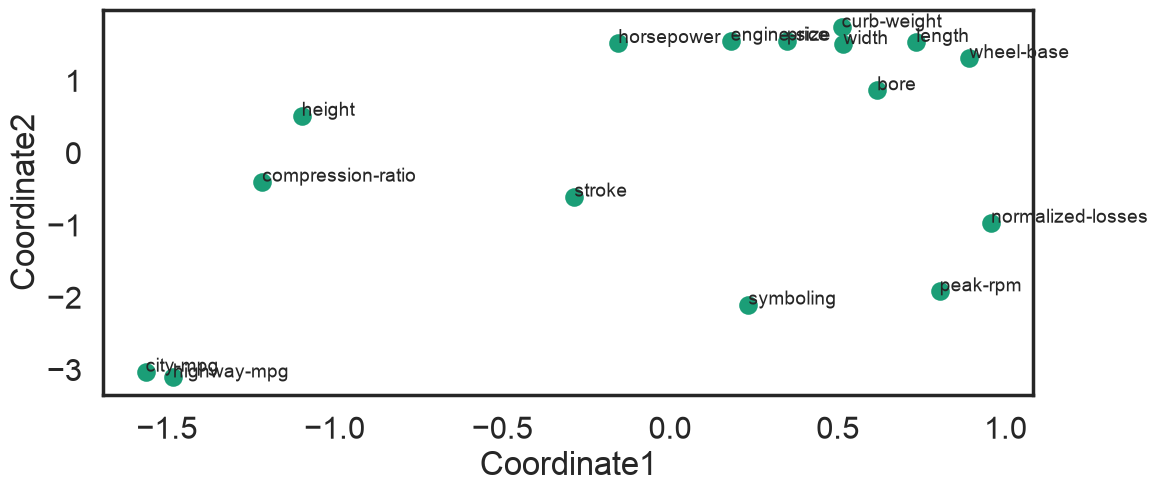

In [38]:
x1 = mds_fit[:,0]
y1 = mds_fit[:,1]

fig, ax = plt.subplots(figsize=(12,5))

dark2_colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02','#a6761d','#666666']
shade_black = '#262626'
ax.scatter(x1,y1, s = 130, zorder=0, c=dark2_colors[0])

for i, txt in enumerate(auto_Y.values):
    ax.annotate(txt[0], (x1[i],y1[i]), zorder=1, size=14, color=shade_black)
    
ax.set_xlabel('Coordinate1')
ax.set_ylabel('Coordinate2');

Positive correlated objects are close together on the same side of the plot.

[Back to Top](#top)
<a id="sammons"></a>

## Sammons Mapping

### Algorithm

Sammons mapping is a category of non-metric MDS. Compared to MDS, Sammon’s distance takes different approach in distance normalization. It uses the x distance instead of y. Formula for MDS:

<img src='img/stress-function.png' width="400" />

More info:

* Sammon Mapping in R: https://stat.ethz.ch/R-manual/R-devel/library/MASS/html/sammon.html

### Strengths and weaknesses

Sammons Mapping tends to preserve local distances better than metric MDS.

### Available parameters

The main Sammons Mapping parameters are similar to MDS:

* `n_components` - number of components in which to immerse the dissimilarities
* `dissimilarity` - Sammons mapping by default computes the dissimilarity matrix from data passed to `fit` and `fit_transform`. If you'd rather compute the dissimilarity matrix yourself, you can set this parameter to "euclidean" instead.

### Example

In [39]:
f = plt.figure()
f.clear()
plt.close(f)

In [40]:
#https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html
# ----------------------------------------------------------------------
# Scale and visualize the embedding vectors
def plot_embedding(X, y, title=None):
    x_min, x_max = np.min(X, 0), np.max(X, 0)
    X = (X - x_min) / (x_max - x_min)

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111)
    for i in range(X.shape[0]):
        plt.text(X[i, 0], X[i, 1], str(y[i]),
                 color=plt.cm.Set1(y[i] / 10.),
                 fontdict={'weight': 'bold', 'size': 9})

    if hasattr(offsetbox, 'AnnotationBbox'):
        # only print thumbnails with matplotlib > 1.0
        shown_images = np.array([[1., 1.]])  # just something big
        for i in range(X.shape[0]):
            dist = np.sum((X[i] - shown_images) ** 2, 1)
            if np.min(dist) < 4e-3:
                # don't show points that are too close
                continue
            shown_images = np.r_[shown_images, [X[i]]]
            imagebox = offsetbox.AnnotationBbox(
                offsetbox.OffsetImage(digits.images[i], cmap=plt.cm.gray_r),
                X[i])
            ax.add_artist(imagebox)

    plt.xticks([]), plt.yticks([])
    if title is not None:
        plt.title(title, fontsize=16)


<Figure size 640x480 with 0 Axes>

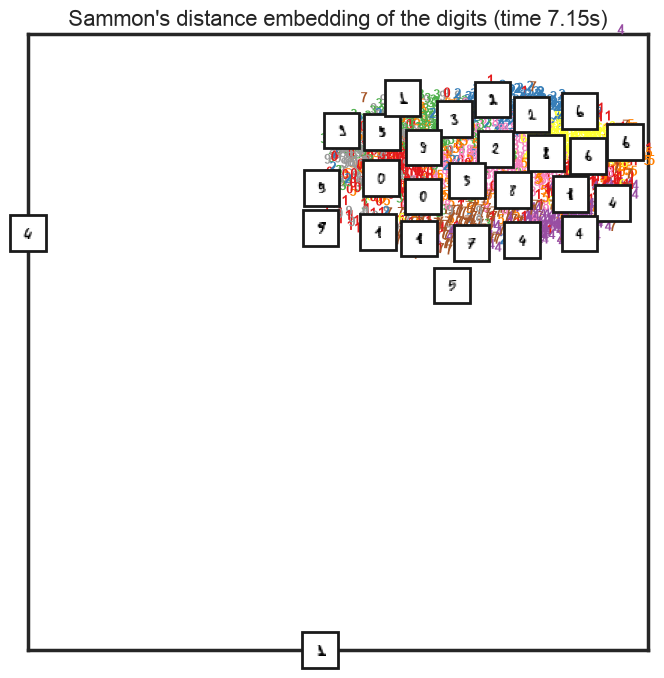

In [41]:
# Source code taken directly from PR to scikit-learn: https://github.com/scikit-learn/scikit-learn/pull/10266
# author: Poom Chiarawongse <eight1911@gmail.com>
# License: BSD

%run SammonsMapping # needs SammonsMapping.py

def sammons_mapping_fit_transform(data):
    return Sammon(n_components=2, dissimilarity="precomputed").fit_transform(data)

t0 = time.time()
X_sammons = sammons_mapping_fit_transform(euclidean_distances(digits_X))

plot_embedding(X_sammons, digits_Y, "Sammon's distance embedding of the digits (time %.2fs)" % (time.time() - t0))

[Back to Top](#top)
<a id="isomap"></a>

## Isomap

### Algorithm

1. Determine the neighbors of each point
2. Construct a neighborhood graph
3. Compute shortest path between two nodes
4. Compute lower-dimensional embedding

### Strengths and weaknesses

Isomap extends MDS in the way it computes pairwise distances. Whereas MDS typically uses straight line Euclidean distances, Isomap computes distance via a neighbor graph, which means it is better able to incorporate the manifold structure in the embedding.

### Available parameters

The major Isomap parameters are:

* `metric` - the metric used to compute pairwise distances (defaults to "minkowski")
* `n_components` - the number of dimensions in the mapping
* `n_neighbors` - determines balance of local vs global structure. It constrains the size of the local neighborhood that Isomap method looks at, when attempting to learn manifold structure. Low values brings out local structure, large values bring out larger neighborhoods while losing the fine detail. Mutually exclusive with `radius`.
* `neighbors_algorithm` - algorithm to use for nearest neighbor search.
* `path_method` - method to use in finding shortest path
* `radius` - limits the distance apart points can be in order to be considered neighbors in the neighbor graph. Mutually exclusive with `n_neighbors`.

More parameters listed in the [scikit-learn docs](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html).

### Example

In [42]:
def isomap_fit_transform(data):
    return Isomap(n_components=2).fit_transform(data)

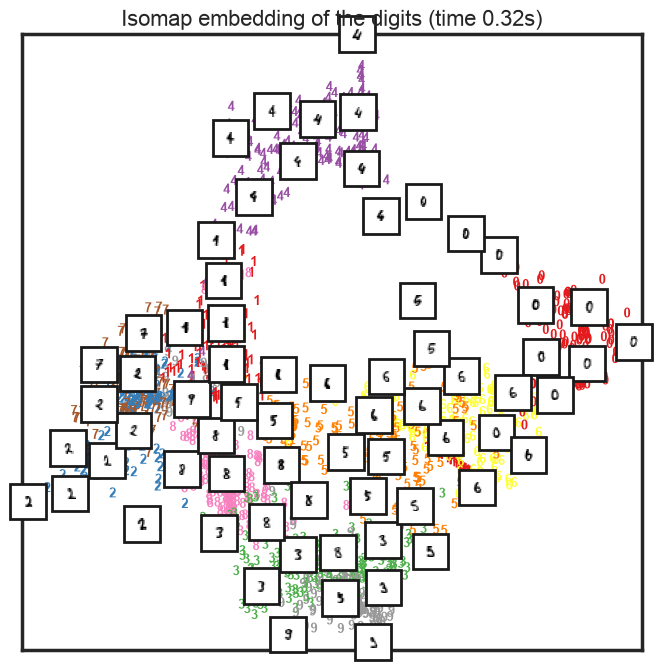

In [43]:
t0 = time.time()
isomap_mapping = isomap_fit_transform(digits_X)
plot_embedding(isomap_mapping, digits_Y, "Isomap embedding of the digits (time %.2fs)" % (time.time() - t0))

With this example, the plot generated by data reduced with Isomap may not impress you. The earlier t-SNE method worked better, and while we didn't try UMAP with this data, I expect UMAP to do at least as well as t-SNE with this data. 

So why learn about less competitive techniques like Isomap? It's about knowing when to use them. Let's look at data that exists as a 2D manifold embedded in 3D space. Think of a 3D dataset where each datapoint represents the location of an air bubble in a sheet cake that gets rolled into a swiss roll. Linear methods like PCA will not be able to represent the 3D structure, but Isomap can help us "unroll" the 3D structure and flatten it into 2D space. 

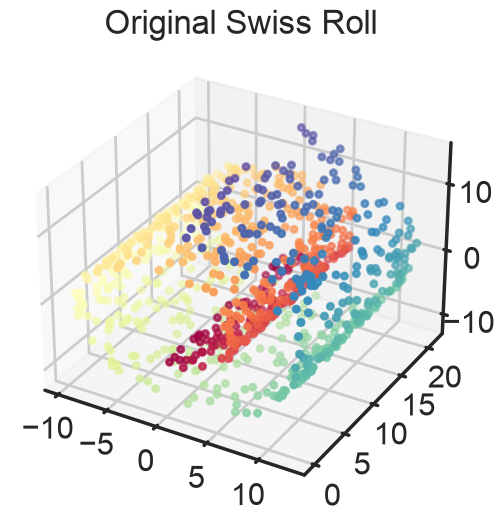

In [44]:
from sklearn.datasets import make_swiss_roll

# Create the Swiss Roll dataset
n_samples = 1000
X, color = make_swiss_roll(n_samples, noise=0.1)

# Visualize swiss roll in "3D"
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.Spectral)
ax.set_title("Original Swiss Roll")
plt.show()

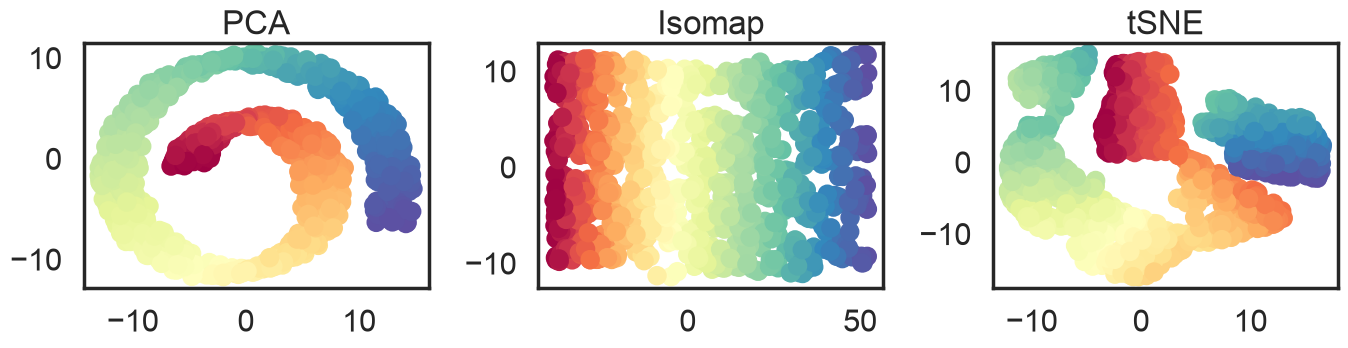

In [45]:
def compare_PCA_tSNE_and_Isomap(data, color, nn=10): 
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 4))
    axes = axes.ravel()
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(data)
    
    tsne = TSNE(n_components=2, random_state=0, perplexity=100, max_iter=1000, learning_rate=100 )
    X_tsne = tsne.fit_transform(data)
    
    isomap = Isomap(n_neighbors=nn, n_components=2)
    X_isomap = isomap.fit_transform(data)
    
    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=color, cmap=plt.cm.Spectral)
    axes[1].scatter(X_isomap[:, 0], X_isomap[:, 1], c=color, cmap=plt.cm.Spectral)
    axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=color, cmap=plt.cm.Spectral)

    
    axes[0].set_title("PCA")
    axes[1].set_title("Isomap")
    axes[2].set_title("tSNE")

    # Adjust the layout to prevent overlapping
    plt.tight_layout()

    # Show the plot
    plt.show()

n_samples = 1000
X, color = make_swiss_roll(n_samples, noise=0.1)
compare_PCA_tSNE_and_Isomap(X, color)

If our jellyroll data contains more noise, what happens to Isomap? 

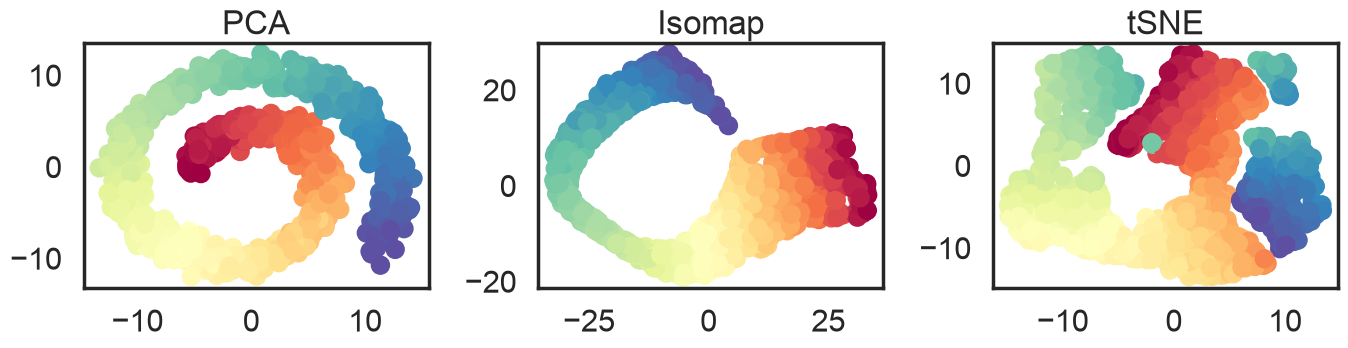

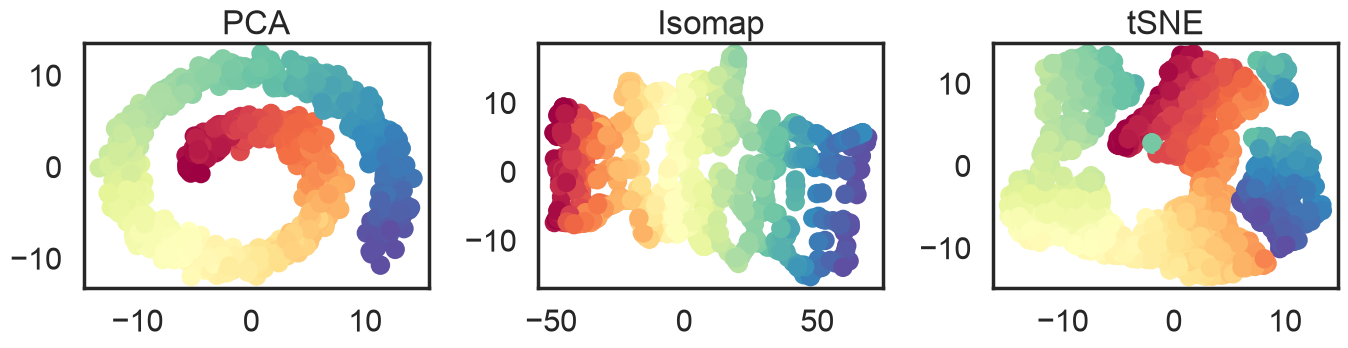

In [46]:
X, color = make_swiss_roll(n_samples, noise=0.6)
compare_PCA_tSNE_and_Isomap(X, color)
compare_PCA_tSNE_and_Isomap(X, color, nn=4) # What difference does this make? 

Dictionary - "manifold" - a collection of points forming a certain kind of set, such as those of a topologically closed surface or an analog of this in three or more dimensions.

>**Some Thoughts on Manifold Methods** 
>
>Though this story and motivation is compelling, in practice manifold learning techniques tend to be finicky enough that they are rarely used for anything more than simple qualitative visualization of high-dimensional data.
>
>The following are some of the particular challenges of manifold learning, which all contrast poorly with PCA:
>
>In manifold learning, there is no good framework for handling missing data. In contrast, there are straightforward iterative approaches for missing data in PCA.
>
>In manifold learning, the presence of noise in the data can "short-circuit" the manifold and drastically change the embedding. In contrast, PCA naturally filters noise from the most important components.
>
>The manifold embedding result is generally highly dependent on the number of neighbors chosen, and there is generally no solid quantitative way to choose an optimal number of neighbors. In contrast, PCA does not involve such a choice.
In manifold learning, the globally optimal number of output dimensions is difficult to determine. In contrast, PCA lets you find the output dimension based on the explained variance.
>
>In manifold learning, the meaning of the embedded dimensions is not always clear. In PCA, the principal components have a very clear meaning.
>
>In manifold learning the computational expense of manifold methods scales as O[N^2] or O[N^3]. For PCA, there exist randomized approaches that are generally much faster (though see the megaman package for some more scalable implementations of manifold learning).
>
>With all that on the table, the only clear advantage of manifold learning methods over PCA is their ability to preserve nonlinear relationships in the data; for that reason I tend to explore data with manifold methods only after first exploring them with PCA.

For more on manifold learning, read:

* http://scikit-learn.org/stable/modules/manifold.html
* https://jakevdp.github.io/PythonDataScienceHandbook/05.10-manifold-learning.html

[Back to Top](#top)
<a id="qualitative"></a>

## Qualitative Comparison

Show different methods applied to the Digits dataset

In [47]:
pca_time = time.time()
pca_results = pca_fit_transform(digits_X)
pca_time = time.time() - pca_time

In [48]:
tsne_time = time.time()
tsne_results = tsne_fit_transform(digits_X)
tsne_time = time.time() - tsne_time

In [49]:
umap_time = time.time()
umap_results = umap_fit_transform(digits_X)
umap_time = time.time() - umap_time

In [50]:
mds_time = time.time()
mds_results = mds_fit_transform(euclidean_distances(digits_X))
mds_time = time.time() - mds_time

In [51]:
sammons_time = time.time()
sammons_mapping_results = sammons_mapping_fit_transform(euclidean_distances(digits_X))
sammons_time = time.time() - sammons_time

In [52]:
isomap_time = time.time()
isomap_results = isomap_fit_transform(digits_X)
isomap_time = time.time() - isomap_time

In [53]:
def plot_mappings(mappings, Y, x_axis_label, y_axis_label):
    fig, axes = plt.subplots(2, 3, figsize=(14, 10))
    
    for (i, mapping) in enumerate(mappings):
        ax = axes[i % 2, i % 3]
        ax.scatter(mapping[1][:, 0], mapping[1][:, 1], s=5, c=Y, alpha=0.5)
        ax.set_title(mapping[0], size=12)
        ax.set_xlabel(x_axis_label, size=12)
        ax.set_ylabel(y_axis_label, size=12)
    
    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    plt.show()

def plot_labelled_points(mappings, Y, x_axis_label, y_axis_label):
    fig, axes = plt.subplots(2, 3, figsize=(14, 11))

    for (i, mapping) in enumerate(mappings):
        shade_black = '#262626'
        ax = axes[i % 2, i % 3]
        ax.scatter(mapping[1][:, 0], mapping[1][:, 1], s = 30)

        for i, txt in enumerate(Y.values):
            ax.annotate(txt[0], (mapping[1][i, 0], mapping[1][i, 1]), zorder=1, color=shade_black, size=12)

        ax.set_title(mapping[0], size=12)
        ax.set_xlabel(x_axis_label, size=12)
        ax.set_ylabel(y_axis_label, size=12)
    
    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    plt.show()

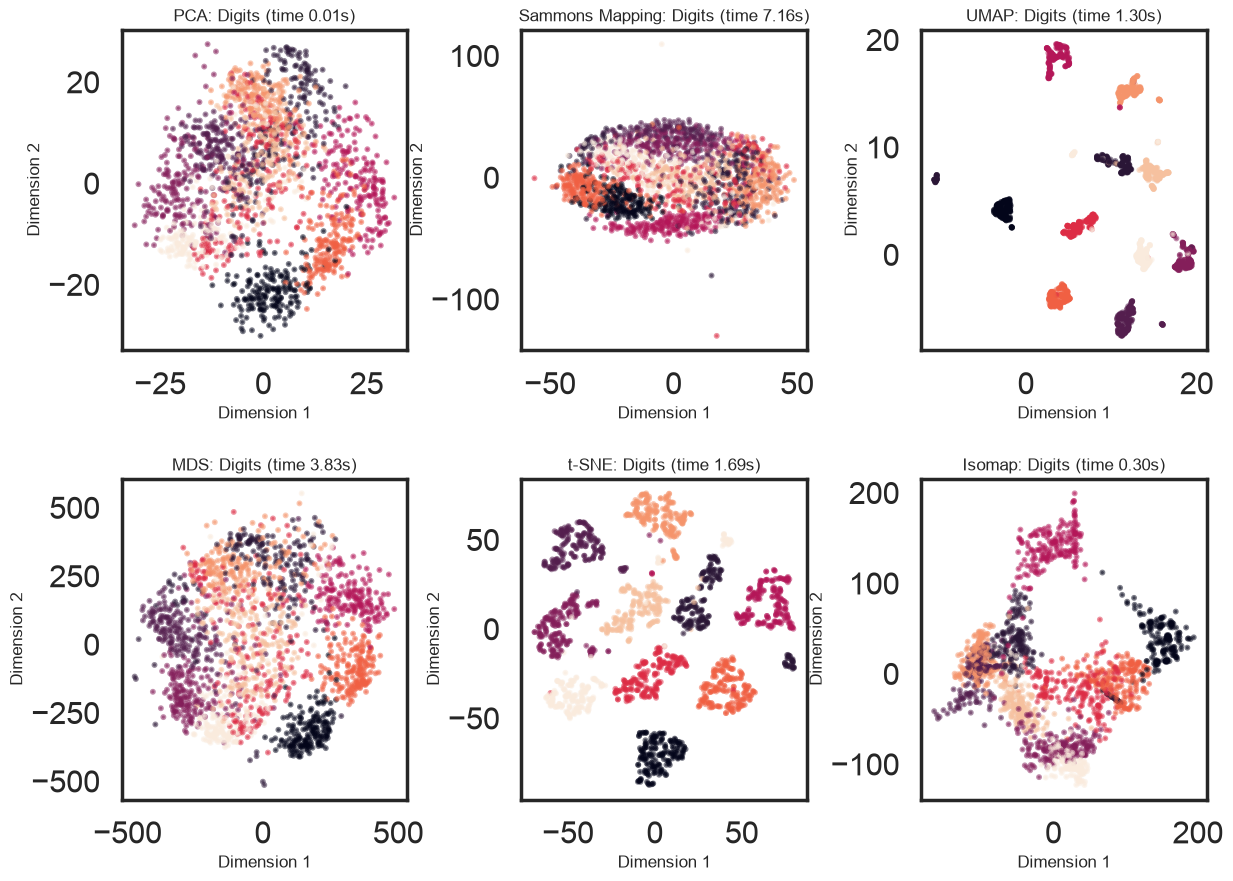

In [54]:
mappings = [
    ('PCA: Digits (time %.2fs)' % pca_time, pca_results),
    ('t-SNE: Digits (time %.2fs)' % tsne_time, tsne_results),
    ('UMAP: Digits (time %.2fs)' % umap_time, umap_results),
    ('MDS: Digits (time %.2fs)' % mds_time, mds_results),
    ('Sammons Mapping: Digits (time %.2fs)' % sammons_time, sammons_mapping_results),
    ('Isomap: Digits (time %.2fs)' % isomap_time, isomap_results)
]
plot_mappings(mappings, digits_Y, 'Dimension 1', 'Dimension 2')

Show different methods applied to the Fashion MNIST dataset

In [55]:
pca_time = time.time()
pca_results = pca_fit_transform(fashion_mnist_X)
pca_time = time.time() - pca_time

In [56]:
tsne_time = time.time()
tsne_results = tsne_fit_transform(fashion_mnist_X)
tsne_time = time.time() - tsne_time

In [57]:
umap_time = time.time()
umap_results = umap_fit_transform(fashion_mnist_X)
umap_time = time.time() - umap_time

In [58]:
mds_time = time.time()
mds_results = mds_fit_transform(euclidean_distances(fashion_mnist_X))
mds_time = time.time() - mds_time

In [59]:
sammons_time = time.time()
sammons_mapping_results = sammons_mapping_fit_transform(euclidean_distances(fashion_mnist_X))
sammons_time = time.time() - sammons_time

In [60]:
isomap_time = time.time()
isomap_results = isomap_fit_transform(fashion_mnist_X)
isomap_time = time.time() - isomap_time

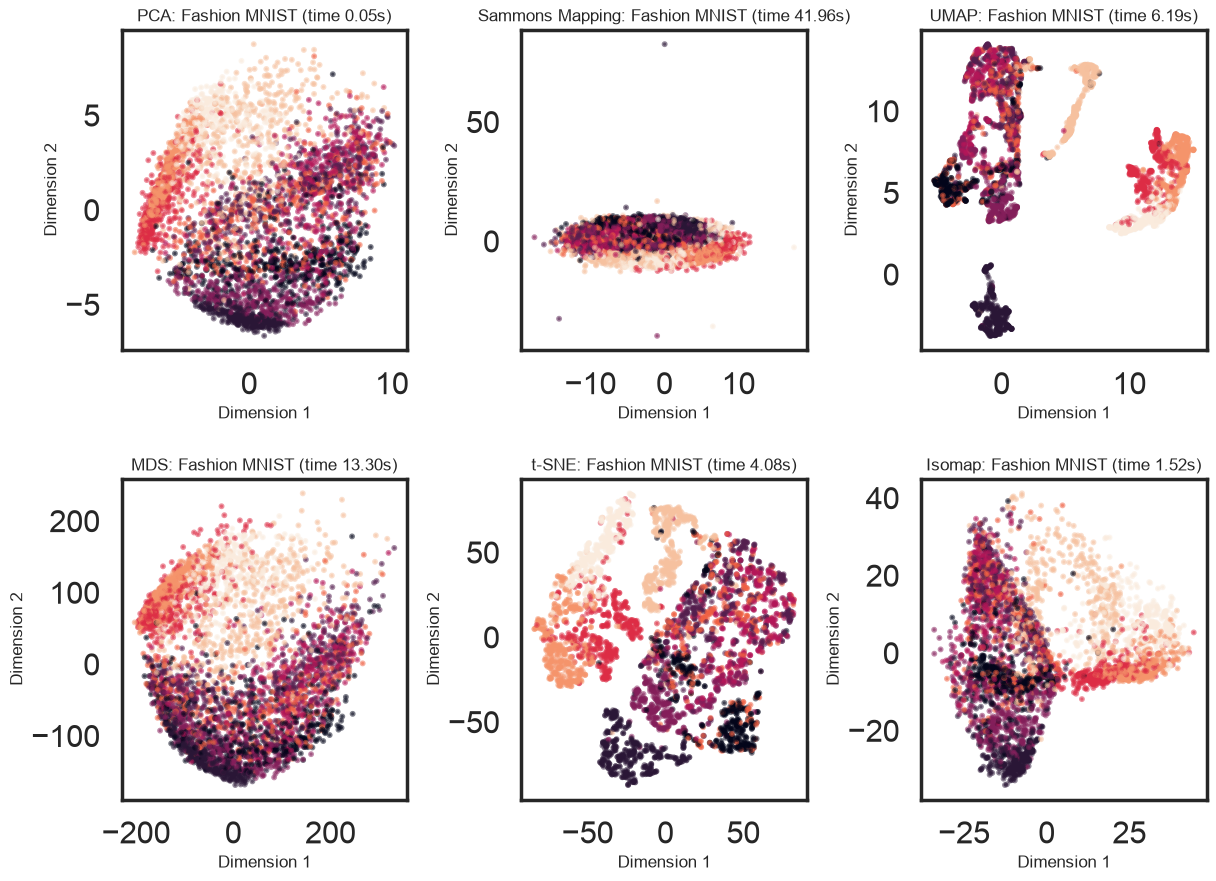

In [61]:
mappings = [
    ('PCA: Fashion MNIST (time %.2fs)' % pca_time, pca_results),
    ('t-SNE: Fashion MNIST (time %.2fs)' % tsne_time, tsne_results),
    ('UMAP: Fashion MNIST (time %.2fs)' % umap_time, umap_results),
    ('MDS: Fashion MNIST (time %.2fs)' % mds_time, mds_results),
    ('Sammons Mapping: Fashion MNIST (time %.2fs)' % sammons_time, sammons_mapping_results),
    ('Isomap: Fashion MNIST (time %.2fs)' % isomap_time, isomap_results)
]
plot_mappings(mappings, fashion_mnist_Y, 'Dimension 1', 'Dimension 2')

Show different methods applied to the USCities dataset

In [62]:
pca_time = time.time()
pca_results = pca_fit_transform(uscitiesd_X)
pca_time = time.time() - pca_time

In [63]:
tsne_time = time.time()
tsne_results = tsne_fit_transform(uscitiesd_X)
tsne_time = time.time() - tsne_time

In [64]:
umap_time = time.time()
umap_results = umap_fit_transform(uscitiesd_X)
umap_time = time.time() - umap_time

In [65]:
mds_time = time.time()
mds_results = mds_fit_transform(euclidean_distances(uscitiesd_X))
mds_time = time.time() - mds_time

In [66]:
sammons_time = time.time()
sammons_mapping_results = sammons_mapping_fit_transform(uscitiesd_X)
sammons_time = time.time() - sammons_time

In [67]:
isomap_time = time.time()
isomap_results = isomap_fit_transform(uscitiesd_X)
isomap_time = time.time() - isomap_time

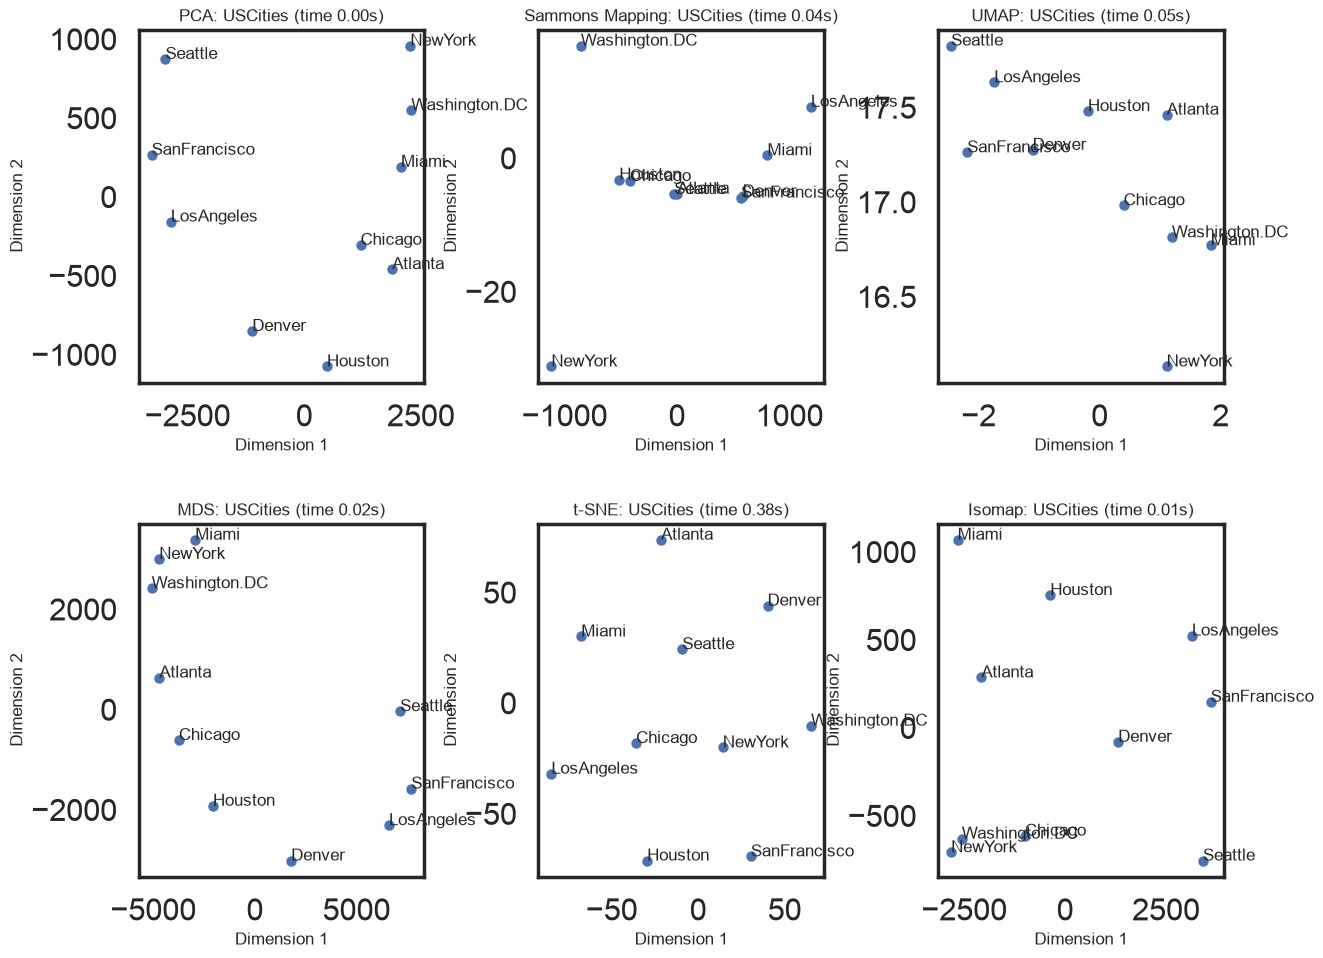

In [68]:
mappings = [
    ('PCA: USCities (time %.2fs)' % pca_time, pca_results),
    ('t-SNE: USCities (time %.2fs)' % tsne_time, tsne_results),
    ('UMAP: USCities (time %.2fs)' % umap_time, umap_results),
    ('MDS: USCities (time %.2fs)' % mds_time, mds_results),
    ('Sammons Mapping: USCities (time %.2fs)' % sammons_time, sammons_mapping_results),
    ('Isomap: USCities (time %.2fs)' % isomap_time, isomap_results)
]
plot_labelled_points(mappings, uscitiesd_Y, 'Dimension 1', 'Dimension 2')

Show different methods applied to the UCI Automobile dataset

In [69]:
pca_time = time.time()
pca_results = pca_fit_transform(auto_X)
pca_time = time.time() - pca_time

In [70]:
tsne_time = time.time()
tsne_results = tsne_fit_transform(auto_X)
tsne_time = time.time() - tsne_time

In [71]:
umap_time = time.time()
umap_results = umap_fit_transform(auto_X)
umap_time = time.time() - umap_time

In [72]:
mds_time = time.time()
mds_results = mds_fit_transform(auto_X)
mds_time = time.time() - mds_time

In [73]:
sammons_time = time.time()
sammons_mapping_results = sammons_mapping_fit_transform(auto_X)
sammons_time = time.time() - sammons_time

In [74]:
isomap_time = time.time()
isomap_results = isomap_fit_transform(auto_X)
isomap_time = time.time() - isomap_time

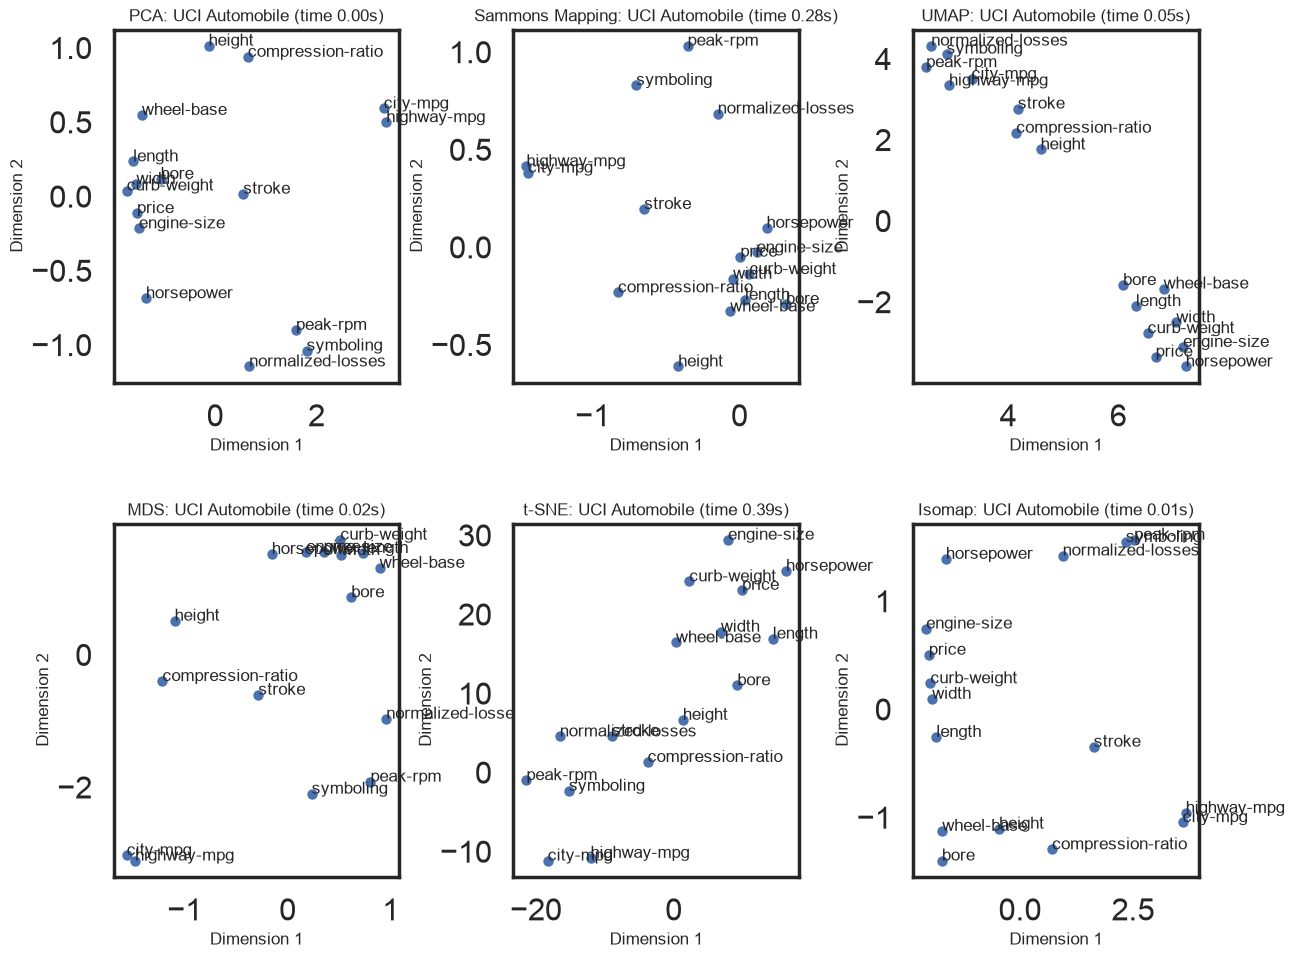

In [75]:
mappings = [
    ('PCA: UCI Automobile (time %.2fs)' % pca_time, pca_results),
    ('t-SNE: UCI Automobile (time %.2fs)' % tsne_time, tsne_results),
    ('UMAP: UCI Automobile (time %.2fs)' % umap_time, umap_results),
    ('MDS: UCI Automobile (time %.2fs)' % mds_time, mds_results),
    ('Sammons Mapping: UCI Automobile (time %.2fs)' % sammons_time, sammons_mapping_results),
    ('Isomap: UCI Automobile (time %.2fs)' % isomap_time, isomap_results)
]
plot_labelled_points(mappings, auto_Y, 'Dimension 1', 'Dimension 2')

[Back to Top](#top)
<a id="shepard"></a>

## Quantitative Comparison with Shepard Plots

How to assess the actual vs. displayed distances

In [76]:
def shepard_plots(mappings, n=1000):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    for (i, mapping) in enumerate(mappings):
        title = mapping[0]
        mapped_distances = mapping[1]
        original_distances = mapping[2]
        ax = axes[i % 2, i % 3]
    
        indices = np.triu_indices(original_distances.shape[0], 1)
        original = original_distances[indices]
        mapped = mapped_distances[indices]
        
        ax.scatter(original[:n], mapped[:n],  s=5, alpha=0.5)
        ax.set_title(title, size=12)
        ax.set_xlabel("Dissimilarities", size=12)
        ax.set_ylabel("Distances", size=12)

    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    plt.show()

In [77]:
pca_results = pca_fit_transform(digits_X)
tsne_results = tsne_fit_transform(digits_X)
umap_results = umap_fit_transform(digits_X)
mds_results = mds_fit_transform(euclidean_distances(digits_X))
sammons_mapping_results = sammons_mapping_fit_transform(euclidean_distances(digits_X))
isomap_results = isomap_fit_transform(digits_X)

mappings = [
    ['Shepard Plot: PCA Digits', euclidean_distances(pca_results), euclidean_distances(digits_X)],
    ['Shepard Plot: t-SNE Digits', euclidean_distances(tsne_results), euclidean_distances(digits_X)],
    ['Shepard Plot: UMAP Digits', euclidean_distances(umap_results), euclidean_distances(digits_X)],
    ['Shepard Plot: MDS Digits', euclidean_distances(mds_results), euclidean_distances(digits_X)],
    ['Shepard Plot: Sammons Mapping Digits', euclidean_distances(sammons_mapping_results), euclidean_distances(digits_X)],
    ['Shepard Plot: Isomap Digits', euclidean_distances(isomap_results), euclidean_distances(digits_X)]
]

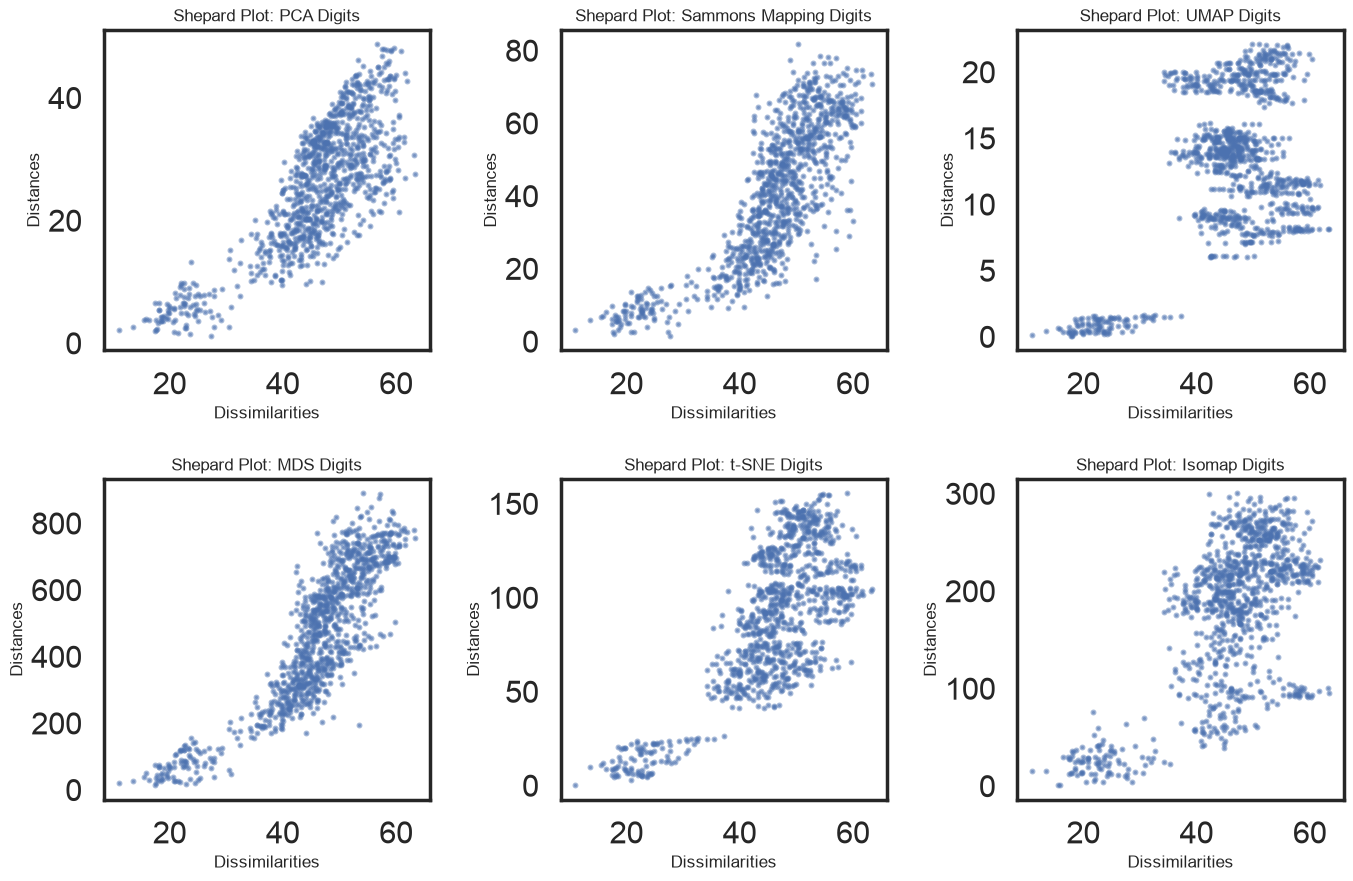

In [78]:
shepard_plots(mappings)

How do we use shepard plots to tell us about the 2D projections? Which of these do a good job plotting truly dissimilar points in N dimensions away from each other in 2D?